# Imports

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import random_split, DataLoader
import torchmetrics
import matplotlib.pyplot as plt
import os
import time

### Model
Flattens each 128×128 RGB image into a 152-dimensional vector. Then feeds it through fully connected layers, mapping 49 152→256 with an RReLU activation, 256→128 with ReLU, 128→100 with ReLU, and finally 100→52, to produce an output of 52 classes.

In [6]:
class FeedForwardNN(nn.Module):
  def __init__(self):
    super(FeedForwardNN, self).__init__()

    self.flatten = nn.Flatten()

    self.linear_stack = nn.Sequential(
        nn.Linear(3 * 128 * 128, 256), #inputs are 128x128 RGB pixels
        nn.RReLU(), # ReLU with randomness in the negative side, helps avoid overfitting (about 5-10% accuracy improvement)
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 100),
        nn.ReLU(),
        nn.Linear(100, 52), # output of 52 classes
    )
  
  def forward(self, x):
    x = self.linear_stack(self.flatten(x))
    return x
     


In [7]:
# set up GPU device if present
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [8]:
model = FeedForwardNN()
model.to(device)

FeedForwardNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_stack): Sequential(
    (0): Linear(in_features=49152, out_features=256, bias=True)
    (1): RReLU(lower=0.125, upper=0.3333333333333333)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=52, bias=True)
  )
)

In [9]:
# Choose loss function and optimizer (for this model we just use basic CEL and SGD as in Dandapanthula’s code)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

### Set up dataset

eight of spades


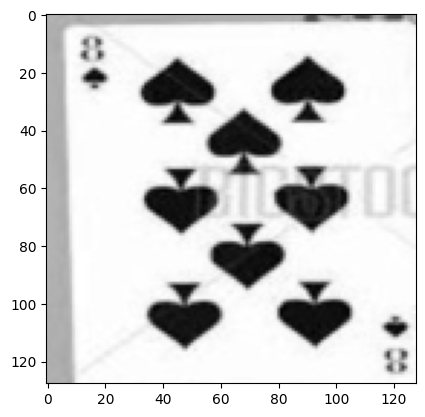

In [10]:
data = []

%run "preprocess.ipynb" # runs our data processing script, which populates the data variable with our dataset

image, label = data[1256]
plt.imshow(image[0], cmap='gray')
print(data.classes[label])

In [11]:
test_count = len(data) // 10 # test 10% of data(ish)
train_count = len(data) - test_count

generator = torch.Generator().manual_seed(42) # random generator for reproducible shuffling

# split dataset randomly
train_dataset, test_dataset = random_split(
    data,
    [train_count, test_count],
    generator=generator 
)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle=True)

### Train/Test Model Functions

In [12]:
# Train model for one epoch
def train_one_epoch(model, loader, loss_fn, optimizer, device):
  model.train() # make sure the model is in training mode and not evaluation mode
  for batch, (inputs, labels) in enumerate(loader):
    # Move training data to GPU if possible
    inputs, labels = inputs.to(device), labels.to(device)

    # Predict and compute loss
    labels_pred = model(inputs)
    loss = loss_fn(labels_pred, labels)

    # Backpropagation to learn weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 50 == 0:
      print(f"Loss: {loss.item():>7f} [{batch*len(inputs):>5d} / {len(loader.dataset):>5d}]")

  return loss.item()

In [13]:
# Test model for one epoch
def test_one_epoch(model, loader, loss_fn, device):
  with torch.no_grad():
    running_loss = 0
    running_correct = 0

    for batch, (inputs, labels) in enumerate(loader):
      # Move training data to GPU
      inputs, labels = inputs.to(device), labels.to(device)

      # Predict and compute loss
      labels_pred = model(inputs)

      # Add to running loss
      loss = loss_fn(labels_pred, labels)
      running_loss += loss

      # Add to running correct count
      correct = (labels_pred.argmax(1) == labels).type(torch.float).sum().item()
      running_correct += correct

    print(f"\nAvg. Validation Loss: {running_loss/len(loader):>7f}")
    print(f"Validation Accuracy: {running_correct/len(loader.dataset)*100:>2f}%\n")

    return running_loss/len(loader), running_correct/len(loader.dataset)*100


### Train Model

In [14]:
# max number of epochs (if using use_old, it will start from the old model's epoch and go to this number)
epochs = 1005

# save each model created?
save_each = False

# remove old models to save space (when using save_each)?
remove_old = True

# use old model as baseline?
use_old = True
old_model_name = "fnn_cards_e999_acc60.pt"
old_model_epoch = 999

if use_old:
  model = torch.load("trained_model/" + str(old_model_name), weights_only=False) # change to the latest epoch saved


In [15]:
# Training loop
train_loss = [] # arrays to track our training and testing loss, for later plotting
test_loss = []

start_time = time.time()
for epoch in range(epochs) if not use_old else range(old_model_epoch+1, epochs): # starts from the old model epoch if use_old is True
  print(f"--------------------\nEPOCH: {epoch}\n--------------------")
  train_loss.append(train_one_epoch(model, train_loader, loss_fn, optimizer, device))
  test_loss.append(test_one_epoch(model, test_loader, loss_fn, device))
  print(f"total time elapsed: {time.time()-start_time:>2f} seconds\n")
  
  # Save model after each epoch (optionally), so if training interrupts before max epochs, the most recent model is saved
  # as well, just in case something goes wrong / laptop gives out / need to do smth else / etc while training, we save every 10 epochs
  # regardless; plus we save the last couple just in case
  if save_each or epochs - epoch < 3 or epoch % 10 == 0:
    print("Saving model...")
    torch.save(model, "trained_model/fnn_cards_e" + str(epoch) + ".pt")

  # remove previous model to save space (100+ epochs would take up over 5gb of space and there's no use keeping them around)
  if save_each and remove_old and epoch >= 1:
    try:
      os.remove("trained_model/fnn_cards_e" + str(epoch-1) + ".pt")
    except Exception as e:
      print("Error removing old model: ", e)


print("Done!")

--------------------
EPOCH: 1000
--------------------
Loss: 0.000056 [    0 /  7227]
Loss: 0.000296 [ 1600 /  7227]
Loss: 0.000117 [ 3200 /  7227]
Loss: 0.000117 [ 4800 /  7227]
Loss: 0.000365 [ 6400 /  7227]

Avg. Validation Loss: 5.535458
Validation Accuracy: 58.104738%

total time elapsed: 11.665562 seconds

Saving model...
--------------------
EPOCH: 1001
--------------------
Loss: 0.000058 [    0 /  7227]
Loss: 0.000109 [ 1600 /  7227]
Loss: 0.000082 [ 3200 /  7227]
Loss: 0.000386 [ 4800 /  7227]
Loss: 0.000056 [ 6400 /  7227]

Avg. Validation Loss: 5.337425
Validation Accuracy: 58.229426%

total time elapsed: 22.539997 seconds

--------------------
EPOCH: 1002
--------------------
Loss: 0.000054 [    0 /  7227]
Loss: 0.000134 [ 1600 /  7227]
Loss: 0.000042 [ 3200 /  7227]
Loss: 0.000210 [ 4800 /  7227]
Loss: 0.000372 [ 6400 /  7227]

Avg. Validation Loss: 5.361763
Validation Accuracy: 58.104738%

total time elapsed: 33.242978 seconds

--------------------
EPOCH: 1003
------------

### Log Results

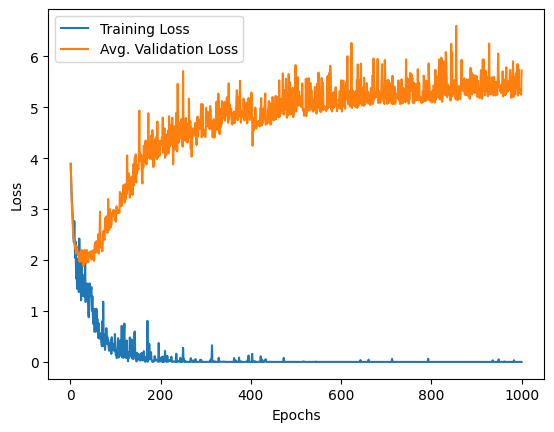

In [175]:
# Plot training loss against epochs
plt.plot([i+1 for i in range(epochs)], train_loss, label="Training Loss")

# Only plot validation loss if there is validation data
if test_loss:
	plt.plot([i+1 for i in range(epochs)], [loss[0].item() for loss in test_loss], label="Avg. Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

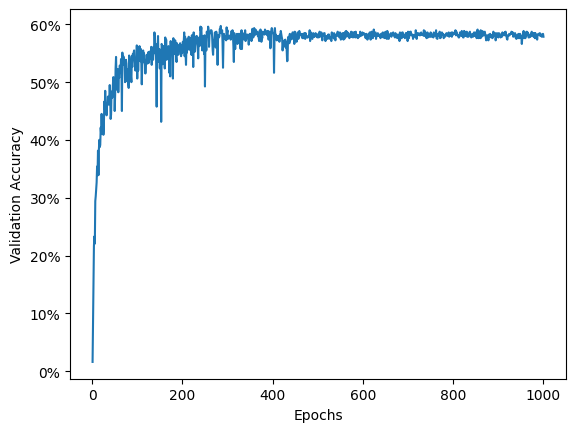

In [176]:
# Plot validation accuracy of model against epochs
import matplotlib.ticker as mtick

_, ax = plt.subplots()

if test_loss:
	plt.plot([i+1 for i in range(epochs)], [loss[1] for loss in test_loss])
	
	plt.xlabel("Epochs")
	plt.ylabel("Validation Accuracy")
	
	ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
	
	plt.show()
else:
	plt.figtext(0.5, 0.5, "No validation data available", ha="center", va="center")
	plt.title("Validation Accuracy")
	plt.show()
	print("Note: To see validation accuracy, uncomment the test_one_epoch line in your training loop")


### Example - Correct

four of hearts


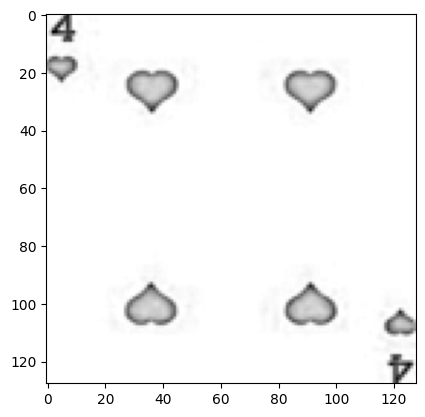

In [30]:
model.eval()

target = 348

plt.imshow(test_dataset[target][0][0], cmap='gray')
print(data.classes[model(test_dataset[target][0].unsqueeze(0)).argmax(dim=1)])

### Example - Incorrect

king of hearts


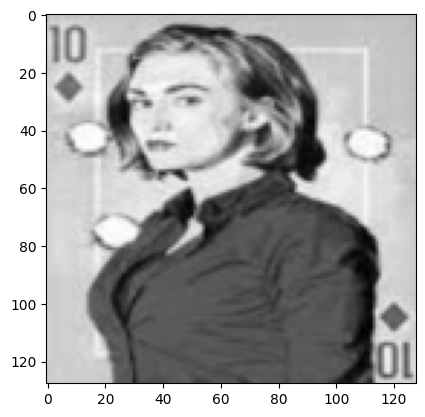

In [42]:
model.eval()

target = 732

plt.imshow(test_dataset[target][0][0], cmap='gray')
print(data.classes[model(test_dataset[target][0].unsqueeze(0)).argmax(dim=1)])

### Calculate Metrics

In [17]:
def get_metric(model, test_loader, device, metric):

    metric.reset()
    model.eval()
    with torch.no_grad():
        for input, lab in test_loader:
            input = input.to(device)
            lab = lab.to(device)

            output = model(input)
            cf, predicted = torch.max(output, 1)

            # Compute metric
            metric.update(predicted, lab)

    return metric.compute().item() * 100

In [22]:
# Use torchmetrics accuracy
accuracy_trainer = torchmetrics.Accuracy(task="multiclass", num_classes=52).to(device)
print(f'Final Accuracy: {get_metric(model, test_loader, device, accuracy_trainer):.4f}%')

Final Accuracy: 58.2294%


In [23]:
# Use torchmetrics precision
precision_trainer = torchmetrics.Precision(task="multiclass", num_classes=52, average="macro").to(device)
print(f'Final Precision: {get_metric(model, test_loader, device, precision_trainer):.4f}%')

Final Precision: 58.6843%


In [24]:
recall_trainer = torchmetrics.Recall(task="multiclass", num_classes=52, average="macro").to(device)
print(f'Final Recall: {get_metric(model, test_loader, device, recall_trainer):.4f}%')

Final Recall: 58.8228%


In [25]:
f1_trainer = torchmetrics.F1Score(task="multiclass", num_classes=52, average='macro').to(device)
print(f'Final F1: {get_metric(model, test_loader, device, f1_trainer):.4f}%')

Final F1: 57.7490%
